# Regression Models
To predict corn returns at time t+1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("enriched_corn_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df

,corn_close,corn_volume,corn_ret,corn_volume_roll_z,corn_rv_5d,corn_rv_20d,month,atr_14,sma_spread,"macd_(12,26,9)",...,d(yc_2_3m),d(yc_curvature),d(T10_yield),d(T2_yield),prod_w_temp,prod_w_tmin,prod_w_tmax,prod_w_prcp,prod_w_rhum,prod_w_wspd
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-02,192.00,3.0,0.000000,-0.534580,0.021779,0.053082,10.0,2.107143,0.028748,2.094062,...,NaN,NaN,NaN,NaN,15.064828,10.321314,19.777591,0.000000,48.411058,9.724337
2000-10-03,195.25,3.0,0.016927,-0.484432,0.018853,0.055290,10.0,1.857143,0.031072,2.314839,...,5.000000e-02,-0.02,0.04,0.02,13.709217,8.389750,19.058552,1.036692,51.591682,11.692289
2000-10-04,199.50,3.0,0.021767,-0.520727,0.028676,0.059405,10.0,1.964286,0.036285,2.608881,...,3.000000e-02,0.06,0.03,0.03,10.763256,7.729175,13.741328,5.597392,60.499126,13.658984
2000-10-05,200.50,3.0,0.005013,-0.520727,0.029111,0.057702,10.0,2.535714,0.043004,2.943438,...,-2.000000e-02,0.00,-0.03,-0.01,7.176648,4.210126,9.872261,12.300664,67.352749,12.139667
2000-10-06,199.50,3.0,-0.004988,-0.520727,0.028466,0.050595,10.0,2.785714,0.045840,3.263189,...,-3.000000e-02,0.01,-0.05,-0.04,3.198147,-0.591903,6.773106,0.000000,47.716438,13.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02,452.25,0.0,-0.004403,-2.807366,0.019868,0.050363,4.0,10.178571,0.001921,6.818618,...,-2.000000e-02,-0.02,-0.02,-0.02,5.324497,2.659980,8.495854,0.490944,51.256284,10.833227
2026-04-06,454.00,126749.0,0.003870,0.403609,0.017178,0.048951,4.0,9.625000,-0.002358,6.369381,...,3.000000e-02,0.00,0.03,0.05,2.606314,0.251393,5.050398,0.000000,30.310008,9.399977
2026-04-07,449.00,172653.0,-0.011013,0.429768,0.015276,0.045451,4.0,9.410714,-0.006572,5.821673,...,-2.000000e-02,-0.02,-0.01,-0.03,2.799057,0.970725,4.823383,0.000000,17.532417,5.801164


We tune all models using 10-split time-series cross-validation on the training sample to preserve chronological ordering and avoid look-ahead bias, then evaluate the selected models on a final holdout test period. The final holdout test period gives us an unbiased approximation of test error which cross-validation cannot since we tune hyperparameters using CV so we cherry-pick models with the lowest CV error and hence it is biased downwards.

In [2]:
feature_cols = [
    'corn_ret', 'corn_volume_roll_z','corn_rv_5d', 'corn_rv_20d', 
    'month',
    'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'yc_10_2', 'yc_2_3m', 'yc_curvature', 
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 'd(T10_yield)', 'd(T2_yield)',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]
response_col = 'corn_ret_t+1'
model_df = df[feature_cols + [response_col]].copy()
if "date" in df.columns:
    model_df = df[["date"] + feature_cols + [response_col]].copy()
    model_df["date"] = pd.to_datetime(model_df["date"])
    model_df = model_df.sort_values("date")
else:
    model_df = model_df.sort_index()
model_df = model_df.dropna(subset=[response_col])

# Final clean feature and response data
X = model_df[feature_cols]
y = model_df[response_col]

# 80-20 Train-Test split for unbiased holdout test period
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Month is a categorical variable
categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]
# Setting up feature preprocessing pipelines
preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # to fill NaN values
        ("scaler", StandardScaler())        # Scaling needed for Lasso, etc. except for Regression Trees & Random Forests
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),   # to fill NaN values
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])
preprocessor_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),    # Scaling not needed here
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

We perform a special type of CV called Time-Series CV which does not shuffle the folds unlike standard K-fold CV to preserve the chronological order of the data and to avoid look-ahead bias caused by future folds being used in the shuffled training set.

In [3]:
# 10-fold Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=10)

# Helper to calculate RMSE for CV
def cv_rmse(model, X, y, cv):
    rmses = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)
    return np.mean(rmses)

# Helper to calculate RMSE, MAE, and R^2 for final holdout test period
def evaluate_holdout(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_r2": r2_score(y_test, preds)
    }

## Lasso, Ridge and Elastic Net Regression

In [4]:
# Lasso
lasso_alphas = np.logspace(-5, -1, 30)
lasso_cv_rmse = []
for alpha in lasso_alphas:
    model = Pipeline([
        ("prep", preprocessor_scaled),
        ("model", Lasso(alpha=alpha, max_iter=20000))
    ])
    lasso_cv_rmse.append(cv_rmse(model, X_train, y_train, tscv))
best_lasso_alpha = lasso_alphas[np.argmin(lasso_cv_rmse)]
print("Best Lasso alpha:", best_lasso_alpha)
best_lasso = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=20000))
])

# Ridge
ridge_alphas = np.logspace(-3, 7, 30)
ridge_cv_rmse = []
for alpha in ridge_alphas:
    model = Pipeline([
        ("prep", preprocessor_scaled),
        ("model", Ridge(alpha=alpha))
    ])
    ridge_cv_rmse.append(cv_rmse(model, X_train, y_train, tscv))
best_ridge_alpha = ridge_alphas[np.argmin(ridge_cv_rmse)]
print("Best Ridge alpha:", best_ridge_alpha)
best_ridge = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", Ridge(alpha=best_ridge_alpha))
])

# Elastic Net
enet_alphas = np.logspace(-5, -1, 20)
enet_l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
enet_results = []
for alpha in enet_alphas:
    for l1_ratio in enet_l1_ratios:
        model = Pipeline([
            ("prep", preprocessor_scaled),
            ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=50000))   # higher iterations needed for convergence
        ])
        rmse = cv_rmse(model, X_train, y_train, tscv)
        enet_results.append((alpha, l1_ratio, rmse))
enet_df = pd.DataFrame(enet_results, columns=["alpha", "l1_ratio", "cv_rmse"])
best_row = enet_df.loc[enet_df["cv_rmse"].idxmin()]
best_enet_alpha = best_row["alpha"]
best_enet_l1 = best_row["l1_ratio"]
print("Best Elastic Net alpha:", best_enet_alpha)
print("Best Elastic Net l1_ratio:", best_enet_l1)
best_enet = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", ElasticNet(alpha=best_enet_alpha, l1_ratio=best_enet_l1, max_iter=20000))
])

Best Lasso alpha: 0.0030391953823131978
Best Ridge alpha: 17433.28822199991
Best Elastic Net alpha: 0.003359818286283781
Best Elastic Net l1_ratio: 0.7


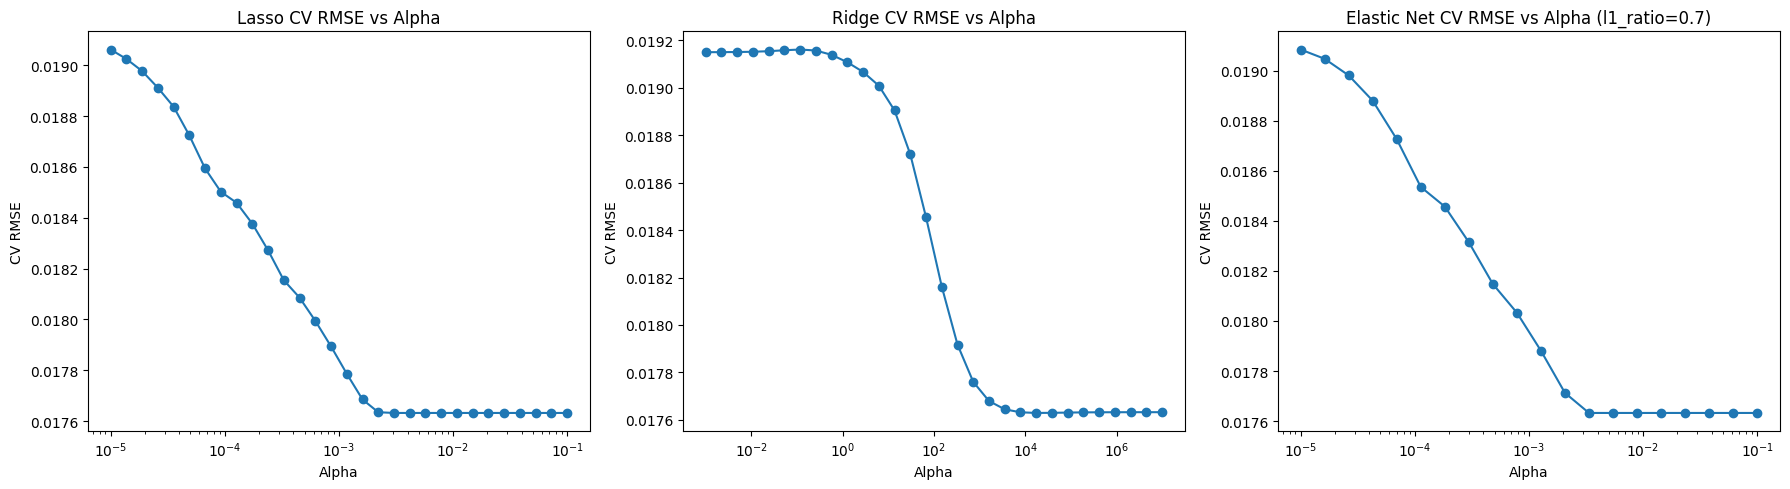

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(lasso_alphas, lasso_cv_rmse, marker="o")
axes[0].set_xscale("log")
axes[0].set_title("Lasso CV RMSE vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("CV RMSE")

axes[1].plot(ridge_alphas, ridge_cv_rmse, marker="o")
axes[1].set_xscale("log")
axes[1].set_title("Ridge CV RMSE vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("CV RMSE")

# Plot best ENet RMSE by alpha for the chosen l1_ratio
enet_best_l1_df = enet_df[enet_df["l1_ratio"] == best_enet_l1].sort_values("alpha")
axes[2].plot(enet_best_l1_df["alpha"], enet_best_l1_df["cv_rmse"], marker="o")
axes[2].set_xscale("log")
axes[2].set_title(f"Elastic Net CV RMSE vs Alpha (l1_ratio={best_enet_l1})")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("CV RMSE")

plt.tight_layout()
plt.show()

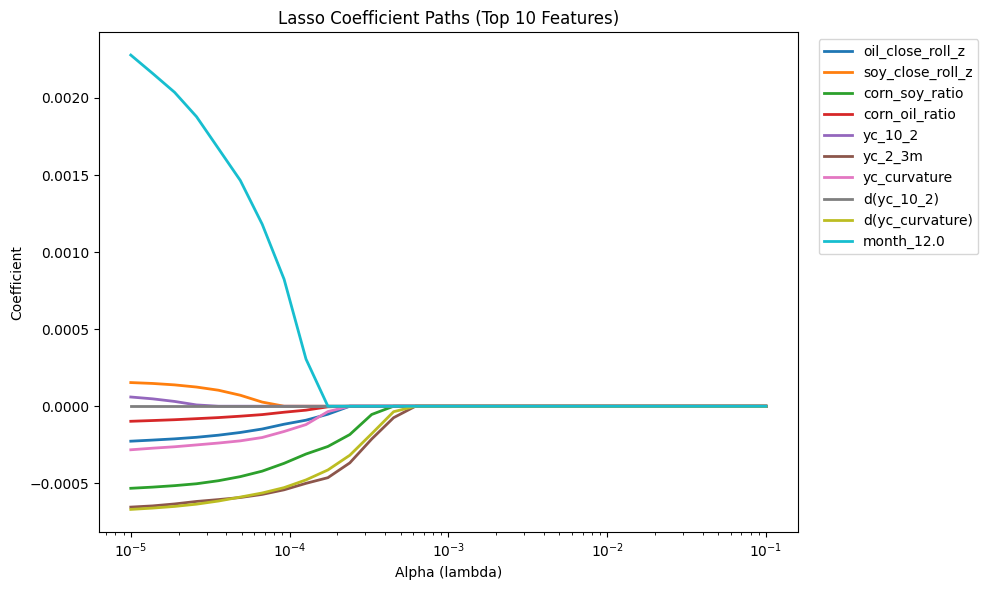

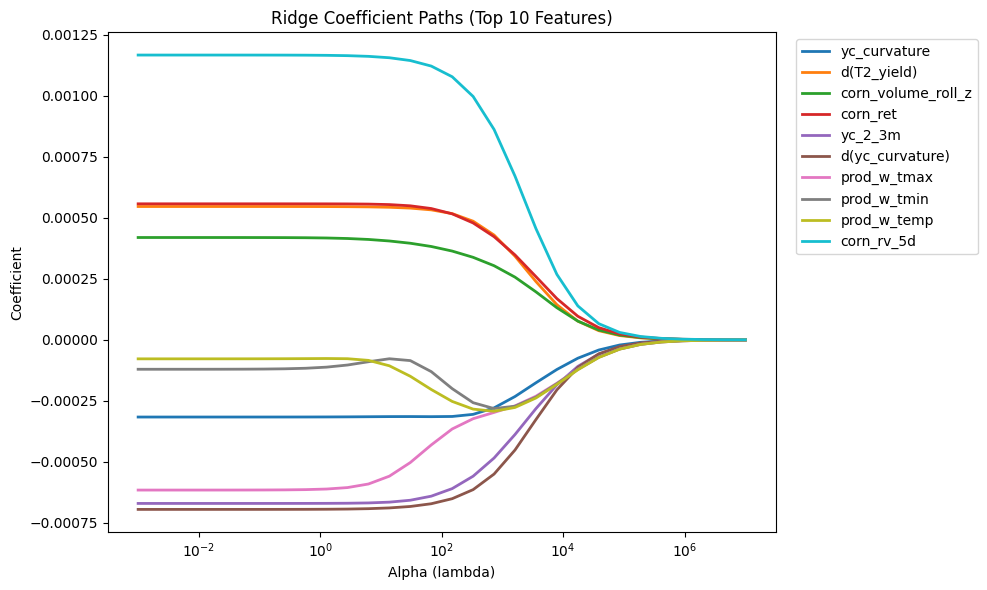

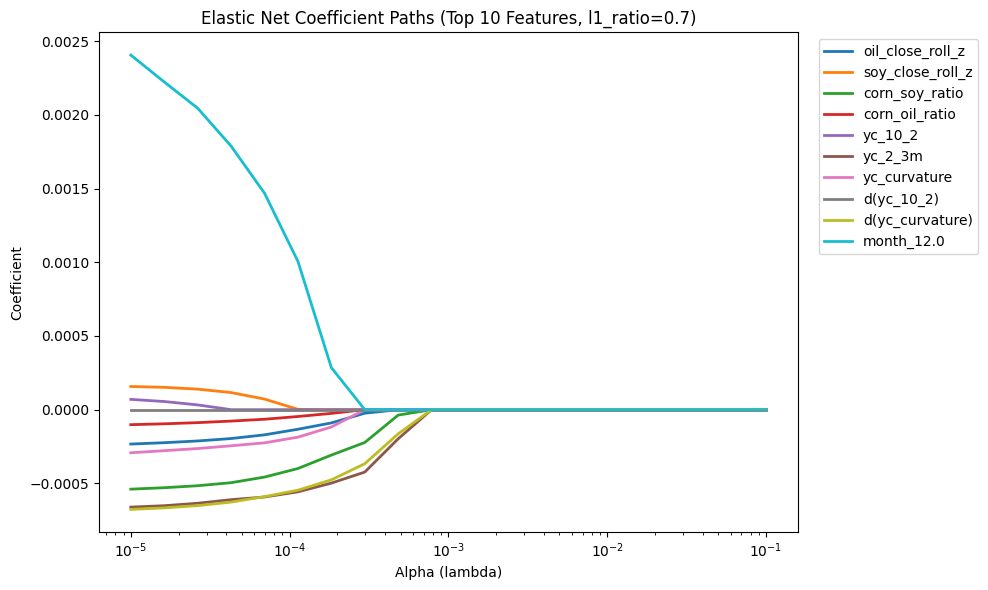

In [6]:
prep_fitted = preprocessor_scaled.fit(X_train)
X_train_proc = prep_fitted.transform(X_train)

# Build post-preprocessing feature names
feature_names_num = numeric_cols
feature_names_cat = prep_fitted.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_cols)

feature_names = list(feature_names_num) + list(feature_names_cat)

def plot_coef_paths(
    X_proc,
    y,
    model_type="lasso",
    alphas=None,
    l1_ratio=0.7,
    feature_names=None,
    top_n=10,
    title=None
):
    """
    Plot coefficient paths for Lasso / Ridge / Elastic Net.
    Only plots top_n features based on best-model absolute coefficient size.
    """
    if alphas is None:
        raise ValueError("alphas must be provided")

    coef_path = []

    # Fit path
    for alpha in alphas:
        if model_type == "lasso":
            mdl = Lasso(alpha=alpha, max_iter=50000)
        elif model_type == "ridge":
            mdl = Ridge(alpha=alpha)
        elif model_type == "enet":
            mdl = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=50000)
        else:
            raise ValueError("model_type must be one of: 'lasso', 'ridge', 'enet'")

        mdl.fit(X_proc, y)
        coef_path.append(mdl.coef_)

    coef_path = np.array(coef_path)

    # Find best alpha model again for labeling top features
    if model_type == "lasso":
        best_model = Lasso(alpha=best_lasso_alpha, max_iter=50000).fit(X_proc, y)
    elif model_type == "ridge":
        best_model = Ridge(alpha=best_ridge_alpha).fit(X_proc, y)
    else:
        best_model = ElasticNet(alpha=best_enet_alpha, l1_ratio=best_enet_l1, max_iter=50000).fit(X_proc, y)

    top_idx = np.argsort(np.abs(best_model.coef_))[-top_n:]

    plt.figure(figsize=(10, 6))
    for j in top_idx:
        label = feature_names[j] if feature_names is not None else f"X{j}"
        plt.plot(alphas, coef_path[:, j], lw=2, label=label)

    plt.xscale("log")
    plt.xlabel("Alpha (lambda)")
    plt.ylabel("Coefficient")
    plt.title(title if title else f"{model_type.title()} Coefficient Paths")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_coef_paths(
    X_train_proc, y_train,
    model_type="lasso",
    alphas=lasso_alphas,
    feature_names=feature_names,
    top_n=10,
    title="Lasso Coefficient Paths (Top 10 Features)"
)

plot_coef_paths(
    X_train_proc, y_train,
    model_type="ridge",
    alphas=ridge_alphas,
    feature_names=feature_names,
    top_n=10,
    title="Ridge Coefficient Paths (Top 10 Features)"
)

plot_coef_paths(
    X_train_proc, y_train,
    model_type="enet",
    alphas=enet_alphas,
    l1_ratio=best_enet_l1,
    feature_names=feature_names,
    top_n=10,
    title=f"Elastic Net Coefficient Paths (Top 10 Features, l1_ratio={best_enet_l1})"
)

## Regression Trees and Random Forest

Best Tree depth: 1
Best Tree min_samples_leaf: 5
Best Tree CV RMSE: 0.017648876596564587


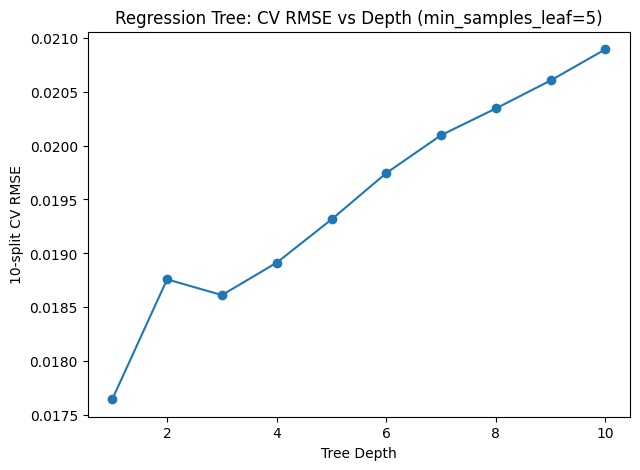

In [7]:
tree_results = []
for depth in range(1, 11):
    for leaf in [5, 10, 20, 40]:
        model = Pipeline([
            ("prep", preprocessor_tree),
            ("model", DecisionTreeRegressor(
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=1
            ))
        ])
        rmse = cv_rmse(model, X_train, y_train, tscv)
        tree_results.append((depth, leaf, rmse))
tree_df = pd.DataFrame(tree_results, columns=["max_depth", "min_samples_leaf", "cv_rmse"])
best_tree_row = tree_df.loc[tree_df["cv_rmse"].idxmin()]
best_tree_depth = int(best_tree_row["max_depth"])
best_tree_leaf = int(best_tree_row["min_samples_leaf"])
best_tree = Pipeline([
    ("prep", preprocessor_tree),
    ("model", DecisionTreeRegressor(
        max_depth=best_tree_depth,
        min_samples_leaf=best_tree_leaf,
        random_state=1
    ))
])
print("Best Tree depth:", best_tree_depth)
print("Best Tree min_samples_leaf:", best_tree_leaf)
print("Best Tree CV RMSE:", best_tree_row["cv_rmse"])

plot_df = tree_df[tree_df["min_samples_leaf"] == best_tree_leaf].sort_values("max_depth")
plt.figure(figsize=(7,5))
plt.plot(plot_df["max_depth"], plot_df["cv_rmse"], marker="o")
plt.xlabel("Tree Depth")
plt.ylabel("10-split CV RMSE")
plt.title(f"Regression Tree: CV RMSE vs Depth (min_samples_leaf={best_tree_leaf})")
plt.show()

Best RF n_trees: 50
Best RF max_depth: 1
Best RF min_samples_leaf: 20
Best RF CV RMSE: 0.017626796431701085


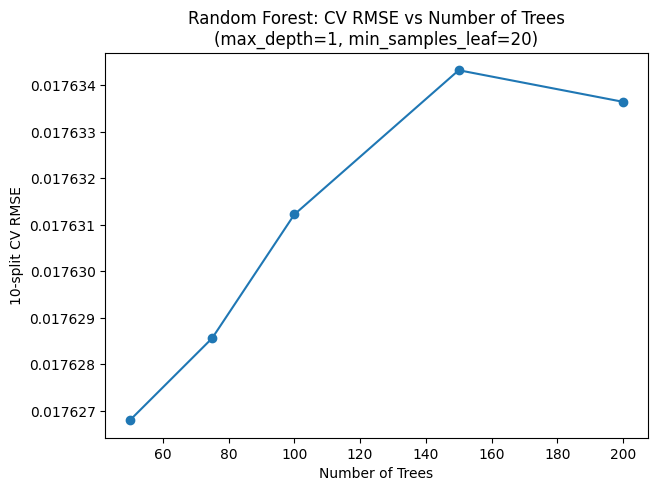

In [8]:
rf_results = []

for n_trees in [50, 75, 100, 150, 200]:
    for depth in [1, 3, 5, 7, None]:
        for leaf in [5, 10, 20]:
            model = Pipeline([
                ("prep", preprocessor_tree),
                ("model", RandomForestRegressor(
                    n_estimators=n_trees,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    max_features="sqrt",   # good default
                    random_state=1,
                    n_jobs=-1
                ))
            ])
            rmse = cv_rmse(model, X_train, y_train, tscv)
            rf_results.append((n_trees, depth, leaf, rmse))
rf_df = pd.DataFrame(rf_results, columns=["n_trees", "max_depth", "min_samples_leaf", "cv_rmse"])
best_rf_row = rf_df.loc[rf_df["cv_rmse"].idxmin()]
best_rf_n = int(best_rf_row["n_trees"])
best_rf_depth = int(None if pd.isna(best_rf_row["max_depth"]) else best_rf_row["max_depth"])
best_rf_leaf = int(best_rf_row["min_samples_leaf"])
best_rf = Pipeline([
    ("prep", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=best_rf_n,
        max_depth=best_rf_depth,
        min_samples_leaf=best_rf_leaf,
        max_features="sqrt",
        random_state=1,
        n_jobs=-1
    ))
])
print("Best RF n_trees:", best_rf_n)
print("Best RF max_depth:", best_rf_depth)
print("Best RF min_samples_leaf:", best_rf_leaf)
print("Best RF CV RMSE:", best_rf_row["cv_rmse"])

plot_rf = rf_df[
    (rf_df["max_depth"].astype(str) == str(float(best_rf_depth))) &
    (rf_df["min_samples_leaf"] == best_rf_leaf)
].sort_values("n_trees")
plt.figure(figsize=(7,5))
plt.plot(plot_rf["n_trees"], plot_rf["cv_rmse"], marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("10-split CV RMSE")
plt.title(f"Random Forest: CV RMSE vs Number of Trees\n(max_depth={best_rf_depth}, min_samples_leaf={best_rf_leaf})")
plt.show()

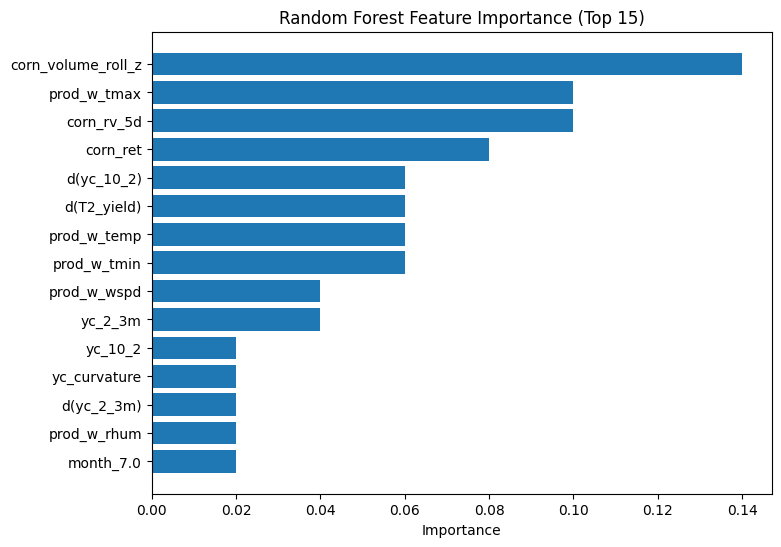

In [9]:
best_rf.fit(X_train, y_train)
prep = best_rf.named_steps["prep"]
rf_model = best_rf.named_steps["model"]
feature_names_num = numeric_cols
feature_names_cat = prep.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_cols)
feature_names = list(feature_names_num) + list(feature_names_cat)
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)
top_rf = rf_importance.head(15).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 15)")
plt.show()

## K-Nearest Neighbours

In [10]:
k_grid = [1, 3, 5, 7, 9, 15, 21, 31, 41, 61, 91, 200, 300]
knn_cv_rmse = []

for k in k_grid:
    model = Pipeline([
        ("prep", preprocessor_scaled),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])
    rmse = cv_rmse(model, X_train, y_train, tscv)
    knn_cv_rmse.append(rmse)

best_k = k_grid[np.argmin(knn_cv_rmse)]
best_knn = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])
best_knn.fit(X_train, y_train)
print("Best K:", best_k)
print("Best CV RMSE:", min(knn_cv_rmse))

Best K: 300
Best CV RMSE: 0.01762453246935111


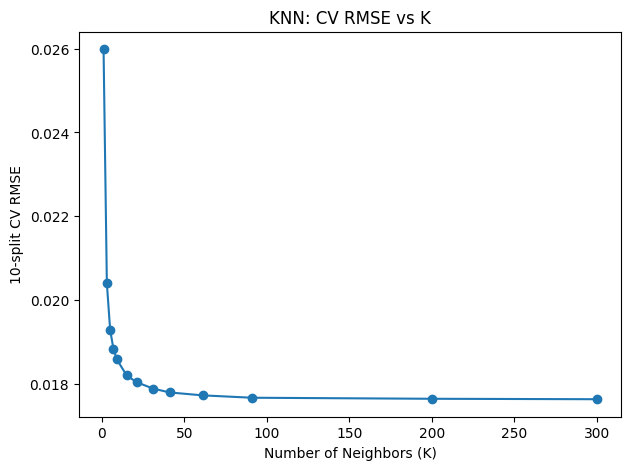

In [11]:
plt.figure(figsize=(7,5))
plt.plot(k_grid, knn_cv_rmse, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("10-split CV RMSE")
plt.title("KNN: CV RMSE vs K")
plt.show()

## Holdout Sample Results

In [12]:
lasso_res = evaluate_holdout("Lasso Regression", best_lasso, X_train, y_train, X_test, y_test)
ridge_res = evaluate_holdout("Ridge Regression", best_ridge, X_train, y_train, X_test, y_test)
enet_res = evaluate_holdout("Elastic Net Regression", best_enet, X_train, y_train, X_test, y_test)
tree_res = evaluate_holdout("Regression Tree", best_tree, X_train, y_train, X_test, y_test)
rf_res = evaluate_holdout("Random Forest", best_rf, X_train, y_train, X_test, y_test)
knn_res = evaluate_holdout("KNN Regression", best_knn,  X_train, y_train, X_test, y_test)
results = pd.DataFrame([lasso_res, ridge_res, enet_res, tree_res, rf_res, knn_res])
results

,model,test_rmse,test_mae,test_r2
0,Lasso Regression,0.017628,0.012097,-0.000488
1,Ridge Regression,0.017630,0.012123,-0.000683
2,Elastic Net Regression,0.017628,0.012097,-0.000488
3,Regression Tree,0.017648,0.012177,-0.002649
4,Random Forest,0.017616,0.012102,0.000933
5,KNN Regression,0.017579,0.012116,0.005159
